# 🎨 PyTorch Neural Style Transfer
**chainer-gogh の PyTorch 移植版**  
論文: [A Neural Algorithm of Artistic Style (Gatys et al., 2015)](https://arxiv.org/abs/1508.06576)

### 1. ライブラリのインポート

In [1]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms

torch.backends.cudnn.enabled = False

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch version: 1.5.1
GPU available: True


### 2. パラメータ設定

In [2]:
CONTENT_IMAGE = "cat.png"   # コンテンツ画像のパス
STYLE_IMAGE   = "style_0.png"     # スタイル画像のパス
OUTPUT_DIR    = "output"        # 出力ディレクトリ
WIDTH         = 512             # 生成画像サイズ（正方形の一辺）
MAX_ITER      = 5000            # 最適化イテレーション数
LR            = 10.0            # 学習率
LAM           = 0.0001          # コンテンツ重み（大きいほどコンテンツに近づく）
GPU_ID        = 1               # GPU番号

os.makedirs(OUTPUT_DIR, exist_ok=True)

if GPU_ID >= 0 and torch.cuda.is_available():
    device = torch.device(f"cuda:{GPU_ID}")
    print(f"✅ GPU使用: cuda:{GPU_ID}")
else:
    device = torch.device("cpu")
    print("✅ CPU使用")


✅ GPU使用: cuda:1


### 3. 画像ユーティリティ関数

In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def load_image(path: str, width: int, device: torch.device):
    """画像を読み込み、正方形にパディングしてテンソルに変換する。"""
    img = Image.open(path).convert("RGB")
    orig_w, orig_h = img.size

    if orig_w >= orig_h:
        new_w = width
        new_h = width * orig_h // orig_w
    else:
        new_w = width * orig_w // orig_h
        new_h = width

    img = img.resize((new_w, new_h), Image.LANCZOS)
    img_np = np.asarray(img, dtype=np.float32) / 255.0

    canvas = np.zeros((width, width, 3), dtype=np.float32)
    if orig_w >= orig_h:
        canvas[width - new_h:, :new_w, :] = img_np
    else:
        canvas[:new_h, width - new_w:, :] = img_np

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])
    tensor = transform(canvas).unsqueeze(0).to(device)
    return tensor, new_w, new_h

def tensor_to_pil(tensor: torch.Tensor, width: int,
                   new_w: int, new_h: int, orig_w_larger: bool) -> Image.Image:
    """テンソルを PIL Image に変換（元の縦横比でクロップ）。"""
    mean = torch.tensor(IMAGENET_MEAN, device=tensor.device).view(1, 3, 1, 1)
    std  = torch.tensor(IMAGENET_STD,  device=tensor.device).view(1, 3, 1, 1)
    img = (tensor.detach() * std + mean).squeeze(0).permute(1, 2, 0)
    img = img.cpu().numpy()
    img = np.clip(img * 255, 0, 255).astype(np.uint8)
    if orig_w_larger:
        crop = img[width - new_h:, :new_w, :]
    else:
        crop = img[:new_h, width - new_w:, :]
    return Image.fromarray(crop)

def save_image(tensor, width, new_w, new_h, orig_w_larger, out_dir, iteration):
    pil = tensor_to_pil(tensor, width, new_w, new_h, orig_w_larger)
    path = os.path.join(out_dir, f"im_{iteration:05d}.png")
    pil.save(path)
    return path

print("✅ ユーティリティ関数を定義しました")

✅ ユーティリティ関数を定義しました


### 4. VGG16 特徴抽出モデル

In [5]:
def gram_matrix(input):
    """
    グラム行列（スタイルの特徴量）を計算する関数
    """
    # a: バッチサイズ, b: 特徴マップの数, c, d: 特徴マップの縦横サイズ
    a, b, c, d = input.size()
    # 行列を平坦化して計算しやすい形に変形
    features = input.view(a * b, c * d)
    # 内積を計算（グラム行列）
    G = torch.mm(features, features.t())
    # 要素数で割って正規化
    return G.div(a * b * c * d)

class VGGFeatureExtractor(nn.Module):
    # content loss の重み (layer ごと)
    alpha = [0.0, 0.0, 1.0, 1.8]
    # style  loss の重み (layer ごと)
    beta = [5.0, 5.0, 15, 15.0]

    def __init__(self):
        super().__init__()
        # pretrained=False にして、自動ダウンロードを止める
        vgg = models.vgg16(pretrained=False)
        
        # 手動でダウンロードしたファイルを読み込む
        vgg.load_state_dict(torch.load('vgg16-397923af.pth'))
        
        f = vgg.features
        self.slice1 = nn.Sequential(*list(f)[:4])
        self.slice2 = nn.Sequential(*list(f)[4:9])
        self.slice3 = nn.Sequential(*list(f)[9:16])
        self.slice4 = nn.Sequential(*list(f)[16:23])
        for p in self.parameters():
            p.requires_grad_(False)

    def forward(self, x):
        y1 = self.slice1(x)
        y2 = self.slice2(y1)
        y3 = self.slice3(y2)
        y4 = self.slice4(y3)
        return [y1, y2, y3, y4]

### 5. 入力画像を確認

コンテンツ: (800, 800) → resize後 512x512


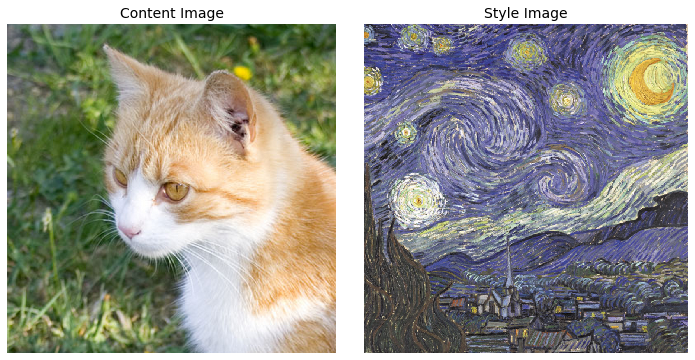

In [6]:
img_content, new_w, new_h = load_image(CONTENT_IMAGE, WIDTH, device)
img_style,   _,    _      = load_image(STYLE_IMAGE,   WIDTH, device)

orig = Image.open(CONTENT_IMAGE)
orig_w_larger = orig.size[0] >= orig.size[1]

print(f"コンテンツ: {orig.size} → resize後 {new_w}x{new_h}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(Image.open(CONTENT_IMAGE))
axes[0].set_title("Content Image", fontsize=14)
axes[0].axis("off")
axes[1].imshow(Image.open(STYLE_IMAGE))
axes[1].set_title("Style Image", fontsize=14)
axes[1].axis("off")
plt.tight_layout()
plt.show()

### 6. スタイル転送の実行

In [7]:
from IPython.display import display, clear_output

# モデルのロード
nn_model = VGGFeatureExtractor().to(device).eval()
print("✅ VGG16 ロード完了")

# content / style の特徴を事前計算
with torch.no_grad():
    feats_content = nn_model(img_content)
    feats_style   = nn_model(img_style)
    style_grams   = [gram_matrix(f) for f in feats_style]

# 生成画像をパラメータとして初期化
img_gen = img_content.clone()
img_gen.requires_grad_(True)

optimizer = optim.Adam([img_gen], lr=LR)

mean_t = torch.tensor(IMAGENET_MEAN, device=device).view(1, 3, 1, 1)
std_t  = torch.tensor(IMAGENET_STD,  device=device).view(1, 3, 1, 1)

loss_history = []

print(f"🎨 最適化開始 ({MAX_ITER} iterations)")
for i in range(MAX_ITER + 1):
    optimizer.zero_grad()
    feats_gen = nn_model(img_gen)

    total_loss = torch.tensor(0.0, device=device)
    for l in range(len(feats_gen)):
        L_content = (LAM * nn_model.alpha[l]
                     * torch.mean((feats_gen[l] - feats_content[l].detach()) ** 2))
        G_gen   = gram_matrix(feats_gen[l])
        G_style = style_grams[l].detach()
        L_style = (nn_model.beta[l] * torch.mean((G_gen - G_style) ** 2))
        total_loss = total_loss + L_content + L_style

    if i < MAX_ITER:
        total_loss.backward()
        optimizer.step()

    # ピクセル値のクリップ
    with torch.no_grad():
        raw = (img_gen * std_t + mean_t).clamp(0.0, 1.0)
        img_gen.data = (raw - mean_t) / std_t

    loss_history.append(total_loss.item())

    # 進捗表示（100イテレーションごと）
    if i % 100 == 0:
        print(f"  iter {i:5d} / {MAX_ITER}  loss = {total_loss.item():.4e}")

    # 画像保存（50イテレーションごと）
    if i % 50 == 0:
        save_image(img_gen, WIDTH, new_w, new_h, orig_w_larger, OUTPUT_DIR, i)

print("✅ 最適化完了！")

✅ VGG16 ロード完了
🎨 最適化開始 (5000 iterations)
  iter     0 / 5000  loss = 2.0569e-03
  iter   100 / 5000  loss = 6.4402e-04
  iter   200 / 5000  loss = 4.1091e-04
  iter   300 / 5000  loss = 3.6407e-04
  iter   400 / 5000  loss = 3.4267e-04
  iter   500 / 5000  loss = 3.3076e-04
  iter   600 / 5000  loss = 3.2390e-04
  iter   700 / 5000  loss = 3.2044e-04
  iter   800 / 5000  loss = 3.1915e-04
  iter   900 / 5000  loss = 3.1917e-04
  iter  1000 / 5000  loss = 3.2672e-04
  iter  1100 / 5000  loss = 3.4103e-04
  iter  1200 / 5000  loss = 3.4112e-04
  iter  1300 / 5000  loss = 3.7630e-04
  iter  1400 / 5000  loss = 3.9166e-04
  iter  1500 / 5000  loss = 4.5468e-04
  iter  1600 / 5000  loss = 4.7267e-04
  iter  1700 / 5000  loss = 5.3500e-04
  iter  1800 / 5000  loss = 6.0961e-04
  iter  1900 / 5000  loss = 6.9730e-04
  iter  2000 / 5000  loss = 7.7319e-04
  iter  2100 / 5000  loss = 8.6290e-04
  iter  2200 / 5000  loss = 9.9002e-04
  iter  2300 / 5000  loss = 1.0766e-03
  iter  2400 / 5000  los

### 7. 結果の表示

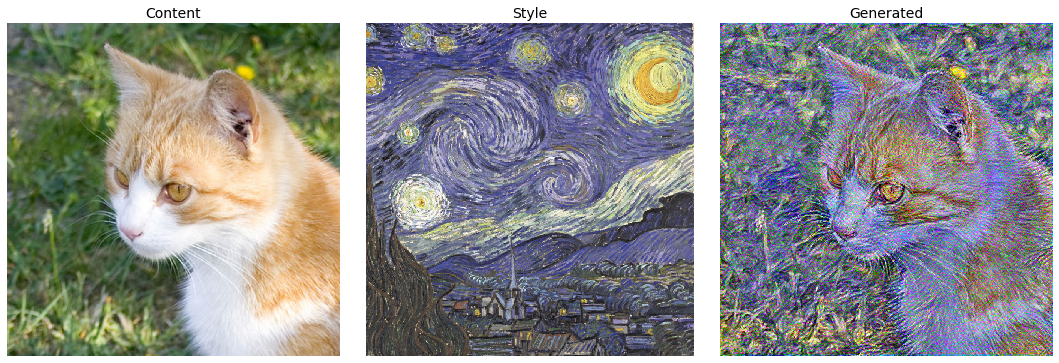

💾 最終結果を保存: output/result_final.png


In [8]:
result_img = tensor_to_pil(img_gen, WIDTH, new_w, new_h, orig_w_larger)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(Image.open(CONTENT_IMAGE))
axes[0].set_title("Content", fontsize=14)
axes[0].axis("off")

axes[1].imshow(Image.open(STYLE_IMAGE))
axes[1].set_title("Style", fontsize=14)
axes[1].axis("off")

axes[2].imshow(result_img)
axes[2].set_title("Generated", fontsize=14)
axes[2].axis("off")

plt.tight_layout()
plt.show()

# 最終結果を保存
final_path = os.path.join(OUTPUT_DIR, "result_final.png")
result_img.save(final_path)
print(f"💾 最終結果を保存: {final_path}")

### 8. Loss の推移

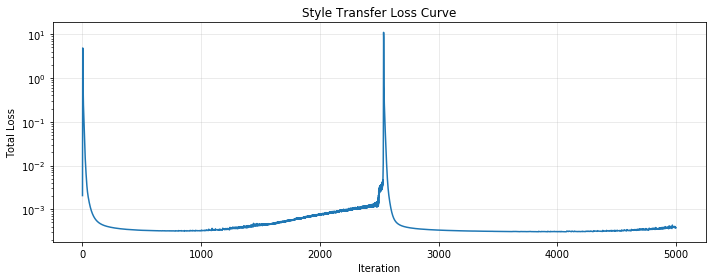

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Total Loss")
plt.title("Style Transfer Loss Curve")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/usr/local/anaconda3/lib/python3.7/site-packages/matplotlib/backends/backend_agg.py:211: RuntimeWarning: Glyph 20013 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/anaconda3/lib/python3.7/site-packages/matplotlib/backends/backend_agg.py:211: RuntimeWarning: Glyph 38291 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/anaconda3/lib/python3.7/site-packages/matplotlib/backends/backend_agg.py:211: RuntimeWarning: Glyph 32080 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/anaconda3/lib/python3.7/site-packages/matplotlib/backends/backend_agg.py:211: RuntimeWarning: Glyph 26524 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/anaconda3/lib/python3.7/site-packages/matplotlib/backends/backend_agg.py:211: RuntimeWarning: Glyph 12398 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/anaconda3/lib/python3.7/site-packages/matplotlib/backends/backend_agg.py:211: Runtim

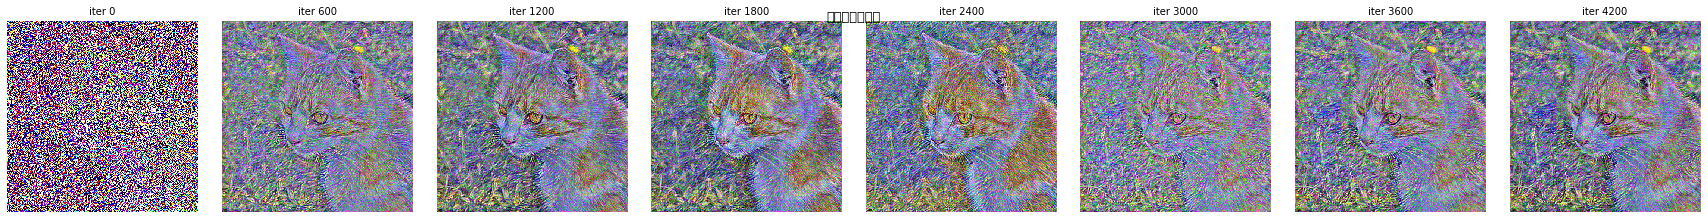

In [10]:
# 保存された中間画像を並べて表示
import glob

saved_files = sorted(glob.glob(os.path.join(OUTPUT_DIR, "im_*.png")))
# 等間隔に最大8枚選ぶ
step = max(1, len(saved_files) // 8)
selected = saved_files[::step][:8]

if selected:
    fig, axes = plt.subplots(1, len(selected), figsize=(3 * len(selected), 3))
    if len(selected) == 1:
        axes = [axes]
    for ax, path in zip(axes, selected):
        ax.imshow(Image.open(path))
        it = int(os.path.splitext(os.path.basename(path))[0].split("_")[1])
        ax.set_title(f"iter {it}", fontsize=10)
        ax.axis("off")
    plt.suptitle("中間結果の推移", fontsize=13)
    plt.tight_layout()
    plt.show()
